In [1]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import re
import time
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC


In [122]:
SEARCH_QUERY = "sony wireless over-ear noise cancelling headphones"
NUM_PAGES = 7
OUTPUT_FILE = "amazon_wireless_headphones.csv"

def clean_rating(text):
    if not text:
        return None
    match = re.search(r"\d+\.\d+", text)
    return float(match.group()) if match else None

options = Options()
options.add_argument("--headless=new")
options.add_argument("--window-size=1920,1080")

driver = webdriver.Chrome(options=options)
wait = WebDriverWait(driver, 15)

rows = []

try:
    for page in range(1, NUM_PAGES + 1):
        #url = f"https://www.amazon.com/s?k=wireless+headphones&rh=n%3A21514463011%2Cp_123%3A233043%257C264616%257C325772&dc&crid=37RAF0SVWP0ZZ&qid=1776023787&rnid=85457740011&sprefix=%2Caps%2C177&ref=sr_nr_p_123_4&ds=v1%3AaS7xNxv3ETbq0rBMp0a1QOxUuJUGO4XFffw2gLNIQOY"
        url = f"https://www.amazon.com/s?k={SEARCH_QUERY.replace(' ', '+')}&page={page}"
        driver.get(url)

        # print("URL:", driver.current_url)
        # print("TITLE:", driver.title)
        # print("CARDS FOUND:", len(driver.find_elements(By.CSS_SELECTOR, 'div[data-component-type="s-search-result"]')))
        # print(driver.page_source[:1500])

        wait.until(
            EC.presence_of_all_elements_located(
                (By.CSS_SELECTOR, 'div[data-component-type="s-search-result"]')
            )
        )

        time.sleep(2)
        product_cards = driver.find_elements(By.CSS_SELECTOR, 'div[data-component-type="s-search-result"]')

        for card in product_cards:
            title = None
            rating = None
            review_count = None
            price = None
            asin = None

            try:
                asin = card.get_attribute("data-asin")
            except:
                pass

           
            try:
                title = card.find_element(By.CSS_SELECTOR, "h2[aria-label]").get_attribute("aria-label")
            except:
                pass

            if not title:
                h2_tags = card.find_elements(By.CSS_SELECTOR, "h2 span")
                title_parts = []

                for el in h2_tags:
                    text = el.text.strip()
                    if text and text.lower() != "sponsored ad -":
                        title_parts.append(text)

                title = " ".join(title_parts) if title_parts else None

            rating_text = None
            selectors_to_try = [
                "span.a-icon-alt",
                "i span.a-icon-alt",
                '[aria-label*="out of 5 stars"]',
                '[aria-label*="stars"]'
            ]

            for sel in selectors_to_try:
                try:
                    el = card.find_element(By.CSS_SELECTOR, sel)
                    rating_text = el.text.strip() or el.get_attribute("aria-label")
                    if rating_text:
                        break
                except:
                    continue

            rating = clean_rating(rating_text)

            try:
                review_tag = card.find_element(
                    By.CSS_SELECTOR,
                    'span.a-size-mini.puis-normal-weight-text.s-underline-text'
                )
                
                review_text = review_tag.text.strip()

                review_text = review_text.replace("(", "").replace(")", "").lower()

                if "k" in review_text:
                    number = float(review_text.replace("k", ""))
                    review_count = int(number * 1000)
                else:
                    review_count = int(review_text.replace(",", ""))

            except:
                pass

            try:
                whole = card.find_element(By.CSS_SELECTOR, ".a-price-whole").text
                fraction = card.find_element(By.CSS_SELECTOR, ".a-price-fraction").text
                
                price = float(f"{whole}.{fraction}")

            except:
                pass
        

            if title:
                rows.append({
                    "asin": asin,
                    "title": title,
                    "rating": rating,
                    "number_of_reviews": review_count,
                    "price": price,
                    "page": page,
                    "source": "Amazon"
                })

            

        time.sleep(2)

finally:
    driver.quit()

df = pd.DataFrame(rows)
df.to_csv(OUTPUT_FILE, index=False)
print(f"Saved {len(df)} rows to {OUTPUT_FILE}")


Saved 112 rows to amazon_wireless_headphones.csv


In [123]:
df = pd.read_csv("amazon_wireless_headphones.csv")
df.head(10)

,asin,title,rating,number_of_reviews,price,page,source
0,B0BS1QCFHX,WH-CH720N Noise Canceling Wireless Headphones ...,4.4,15000.0,NaN,1,Amazon
1,B0BS1PRC4L,WH-CH520 Wireless Headphones Bluetooth On-Ear ...,4.5,31300.0,38.00,1,Amazon
2,B0DY8TS92J,WH-CH720N Noise Canceling Wireless Headphones ...,4.4,15000.0,98.00,1,Amazon
3,B0CWVX1GNX,ULT WEAR Over-Ear Noise Canceling Bluetooth He...,4.3,3000.0,NaN,1,Amazon
4,B0BS74M665,WH-CH720N Noise Canceling Wireless Headphones ...,4.4,15000.0,98.00,1,Amazon
5,B0BVPNJP1C,WHCH720N Wireless Over The Ear Noise Canceling...,4.4,1600.0,98.00,1,Amazon
6,B0CFSCT8GQ,WH-CH720NB Noise Canceling Wireless Bluetooth ...,4.5,1300.0,98.00,1,Amazon
7,B0CX1TJXKV,ULT WEAR Over Ear Wireless Noise Canceling Hea...,4.5,2500.0,149.99,1,Amazon
8,B0CWVXTK6Z,ULT WEAR Over-Ear Noise Canceling Bluetooth He...,4.3,3000.0,148.00,1,Amazon
9,B09XS7JWHH,"WH-1000XM5 Premium Noise Canceling Headphones,...",4.2,19200.0,248.00,1,Amazon


In [124]:
df.shape

(112, 7)

In [125]:
display(pd.DataFrame(df.dtypes.astype(str), columns=['dtype']).reset_index().rename(columns={'index':'column'}))

,column,dtype
0,asin,object
1,title,object
2,rating,float64
3,number_of_reviews,float64
4,price,float64
5,page,int64
6,source,object


Checking whether there are duplicate "asin"s -

In [131]:
total = len(df)
unique_asins = df['asin'].nunique(dropna=True)
dup_mask = df['asin'].duplicated(keep=False)
dup_count = dup_mask.sum()

print(f"Total rows: {total}")
print(f"Unique ASINs (excluding NaN): {unique_asins}")
print(f"Rows involved in duplicates: {dup_count}")

if dup_count:
    dup_summary = df.loc[dup_mask, 'asin'].value_counts()
    display(dup_summary.to_frame(name='count'))
    display(df[dup_mask].sort_values('asin').reset_index(drop=True))
else:
    print("No duplicate ASINs found.")

Total rows: 111
Unique ASINs (excluding NaN): 111
Rows involved in duplicates: 0
No duplicate ASINs found.


In [130]:
# keep only the first occurrence for each asin
prev_count = df.shape[0]
df = df.drop_duplicates(subset="asin", keep="first").reset_index(drop=True)
print(f"Dropped {prev_count - df.shape[0]} duplicate rows; new row count: {df.shape[0]}")

Dropped 1 duplicate rows; new row count: 111


Checking for null values across "title", "price", "rating"

In [132]:
# check nulls for requested columns (handle "Price" vs "price" name)
cols_req = ['title', 'price', 'rating']
cols = []
for c in cols_req:
    if c in df.columns:
        cols.append(c)
    elif c == 'price' and 'Price' in df.columns:
        cols.append('Price')
    else:
        print(f"Column not found: {c!r}")

if not cols:
    raise KeyError("None of the requested columns were found in df.")

total = len(df)
null_counts = df[cols].isnull().sum()
null_percent = (null_counts / total * 100).round(2)

summary = pd.DataFrame({
    'column': cols,
    'null_count': null_counts.values,
    'null_percent': null_percent.values
})
display(summary.set_index('column'))

# show rows with any null among these columns (if any)
if summary['null_count'].sum() > 0:
    display(df[df[cols].isnull().any(axis=1)][cols].reset_index())

,null_count,null_percent
column,,
title,0,0.00
price,17,15.32
rating,7,6.31


,index,title,price,rating
0,0,WH-CH720N Noise Canceling Wireless Headphones ...,NaN,4.4
1,3,ULT WEAR Over-Ear Noise Canceling Bluetooth He...,NaN,4.3
2,20,Noise Cancelling Headphones WHCH710N: Wireless...,NaN,4.4
3,21,Sony WH-CH720N/P Bluetooth Wireless Noise-Canc...,59.99,NaN
4,22,WH-CH720N Noise Canceling Wireless Headphones ...,NaN,4.4
5,24,Sony - WH-CH720N Wireless Noise Canceling Head...,59.99,NaN
6,25,"WH1000XM3 Noise Cancelling Headphones, Wireles...",NaN,4.6
7,37,ULT WEAR Wireless Noise Cancelling Over-Ear He...,148.00,NaN
8,38,WH-CH720NL Noise Canceling Wireless Bluetooth ...,NaN,4.5
9,39,WH-CH520 Compact Easy Carrying Wireless Blueto...,NaN,4.5


In [134]:
price_col = 'price' if 'price' in df.columns else ('Price' if 'Price' in df.columns else None)
rating_col = 'rating' if 'rating' in df.columns else ('Rating' if 'Rating' in df.columns else None)
required = ['title', price_col, rating_col]

if None in required:
    missing = [k for k in ['title', 'price/range', 'rating'] if (k == 'title' and 'title' not in df.columns) or (k == 'price/range' and price_col is None) or (k == 'rating' and rating_col is None)]
    raise KeyError(f"Required column(s) missing: {missing}")

prev = len(df)
df = df.dropna(subset=['title', price_col, rating_col]).reset_index(drop=True)
print(f"Dropped {prev - len(df)} rows; new row count: {len(df)}")

Dropped 0 rows; new row count: 87


In [ ]:
num_rows_with_nulls = df.isnull().any(axis=1).sum()
print(num_rows_with_nulls)
print(df.shape)

df_nonull = df.dropna().reset_index(drop=True)
df_nonull.shape

36
(166, 7)


36
(166, 7)


(130, 7)

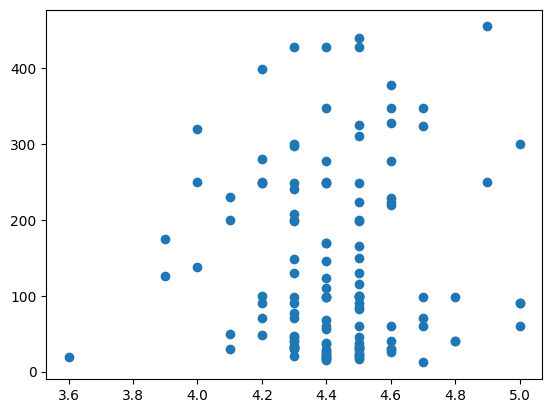

In [ ]:
plt.scatter(df_nonull["rating"], df_nonull["Price"])

In [ ]:
import re
import time
import pandas as pd

from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC

SEARCH_QUERY = "sony wireless over-ear noise cancelling headphones"
NUM_PAGES = 10
OUTPUT_FILE = "walmart_wireless_headphones.csv"

def clean_rating(text):
    if not text:
        return None
    match = re.search(r"\d+\.\d+", text)
    return float(match.group()) if match else None

def clean_review_count(text):
    """
    Handles values like:
    (15.8k) -> 15800
    (9k)    -> 9000
    (873)   -> 873
    (7)     -> 7
    """
    if not text:
        return None

    text = text.strip().lower()
    text = text.replace("(", "").replace(")", "").replace(",", "")

    match = re.search(r"(\d+(\.\d+)?)(k)?", text)
    if not match:
        return None

    number = float(match.group(1))
    if match.group(3) == "k":
        return int(number * 1000)
    return int(number)

options = Options()
options.add_argument("--headless=new")
options.add_argument("--window-size=1920,1080")
options.add_argument("--no-sandbox")
options.add_argument("--disable-dev-shm-usage")

driver = webdriver.Chrome(options=options)
wait = WebDriverWait(driver, 15)

rows = []

try:
    for page in range(1, NUM_PAGES + 1):
        url = f"https://www.walmart.com/search?q={SEARCH_QUERY.replace(' ', '+')}&page={page}"
        driver.get(url)

        # Walmart may render product cards dynamically, so wait for product links / cards.
        wait.until(
            EC.presence_of_all_elements_located(
                (By.CSS_SELECTOR, 'a[href*="/ip/"]')
            )
        )

        time.sleep(2)

        # Find all product links that lead to item pages.
        product_links = driver.find_elements(By.CSS_SELECTOR, 'a[href*="/ip/"]')

        seen = set()

        for link in product_links:
            try:
                href = link.get_attribute("href")
                if not href or href in seen:
                    continue
                seen.add(href)

                # Try to capture a product card container around the link.
                # If the DOM differs, these fallbacks still let you get something useful.
                card = None
                try:
                    card = link.find_element(By.XPATH, "./ancestor::div[.//a[contains(@href, '/ip/')]][1]")
                except:
                    card = link

                title = None
                rating = None
                review_count = None
                price = None

                # TITLE
                try:
                    title = link.text.strip()
                except:
                    pass

                if not title:
                    try:
                        title_el = card.find_element(By.CSS_SELECTOR, "span")
                        title = title_el.text.strip()
                    except:
                        pass

                # PRICE
                # Walmart often exposes price in visible text or nested spans.
                try:
                    price_text = card.text
                    price_match = re.search(r"\$\s?(\d+(?:\.\d{2})?)", price_text)
                    if price_match:
                        price = float(price_match.group(1))
                except:
                    pass

                # RATING
                # Try common patterns first, then fall back to any aria-label-like text.
                try:
                    rating_el = card.find_element(By.CSS_SELECTOR, '[aria-label*="stars"]')
                    rating_text = rating_el.get_attribute("aria-label") or rating_el.text.strip()
                    rating = clean_rating(rating_text)
                except:
                    try:
                        rating_el = card.find_element(By.CSS_SELECTOR, "span")
                        rating_text = rating_el.get_attribute("aria-label") or rating_el.text.strip()
                        rating = clean_rating(rating_text)
                    except:
                        pass

                # REVIEW COUNT
                # Walmart often shows review count near rating in parenthetical form.
                try:
                    card_text = card.text
                    # Example patterns: (15.8K), 1.2K reviews, 873 reviews
                    review_match = re.search(r"\(?\s*(\d+(?:\.\d+)?k?|\d+)\s*\)?\s*reviews?", card_text, re.IGNORECASE)
                    if review_match:
                        review_count = clean_review_count(review_match.group(1))
                    else:
                        paren_match = re.search(r"\((\d+(?:\.\d+)?k?)\)", card_text, re.IGNORECASE)
                        if paren_match:
                            review_count = clean_review_count(paren_match.group(1))
                except:
                    pass

                if title:
                    rows.append({
                        "title": title,
                        "rating": rating,
                        "number of reviews": review_count,
                        "Price": price,
                        "page": page,
                        "source": "Walmart",
                        "url": href
                    })

            except:
                continue

        time.sleep(2)

finally:
    driver.quit()

df = pd.DataFrame(rows).drop_duplicates()
df.to_csv(OUTPUT_FILE, index=False)
print(f"Saved {len(df)} rows to {OUTPUT_FILE}")
print(df.head())

TimeoutException: Message: 
